# Word2Vec Embeddings — Constitution Corpus
DS 5001 Text as Data

## Set Up

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

sns.set_theme(style='white')

In [3]:
data_home  = 'parsed_data'
table_dir  = 'derived_tables'
output_dir = 'models'

OHCO  = ['country_id', 'article_id', 'section_id', 'subsection_id', 'sent_id', 'token_id']
SENTS = OHCO[:5]  

# W2V hyperparameters
N_FEATURES  = 256   
WINDOW      = 2
MIN_COUNT   = 50     
W2V_WORKERS = 1
RANDOM_SEED = 42

## Load Data

In [4]:
CORPUS = pd.read_csv(f'{data_home}/const_TOKEN.csv')
VOCAB  = pd.read_csv(f'{data_home}/const_VOCAB.csv', index_col='term_str')

print('CORPUS:', CORPUS.shape)
print('VOCAB :', VOCAB.shape)

CORPUS: (4263565, 11)
VOCAB : (39730, 17)


In [5]:
corpus_clean = CORPUS.dropna(subset=['term_str']).copy()

sentences = (
    corpus_clean
    .sort_values(OHCO)           
    .groupby(SENTS)['term_str']
    .apply(list)
    .tolist()
)

print(f'Sentences: {len(sentences):,}')
print('Example:  ', sentences[0][:10])

Sentences: 309,287
Example:   ['afghanistan', '2004']


## Train Word2Vec

In [6]:
w2v_model = Word2Vec(
    sentences  = sentences,
    vector_size= N_FEATURES,
    window     = WINDOW,
    min_count  = MIN_COUNT,
    workers    = W2V_WORKERS,
    seed       = RANDOM_SEED,
    sg         = 0, 
)

print(f'Vocabulary size: {len(w2v_model.wv):,}')
print(f'Vector size:     {w2v_model.wv.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 4,172
Vector size:     256


## Build VOCAB_W2V

A table indexed by `term_str` with one column per embedding dimension, restricted to terms that also appear in VOCAB.

In [7]:
w2v_terms = list(w2v_model.wv.index_to_key)

VOCAB_W2V = pd.DataFrame(
    w2v_model.wv.vectors,
    index   = w2v_terms,
    columns = [f'w2v_{i:03d}' for i in range(N_FEATURES)]
)
VOCAB_W2V.index.name = 'term_str'

VOCAB_W2V = VOCAB_W2V.loc[VOCAB_W2V.index.isin(VOCAB.index)]

print('VOCAB_W2V:', VOCAB_W2V.shape)
VOCAB_W2V.head()

VOCAB_W2V: (4172, 256)


,w2v_000,w2v_001,w2v_002,w2v_003,w2v_004,w2v_005,w2v_006,w2v_007,w2v_008,w2v_009,...,w2v_246,w2v_247,w2v_248,w2v_249,w2v_250,w2v_251,w2v_252,w2v_253,w2v_254,w2v_255
term_str,,,,,,,,,,,,,,,,,,,,,
the,-0.566422,0.333305,0.140666,-0.562426,0.189523,0.336922,-0.129148,-0.396496,-0.622009,0.767653,...,1.358779,-0.312667,0.425982,-0.285130,-0.379378,-0.452966,-0.219705,-0.238660,-0.463977,-0.100918
of,-0.062500,-0.832995,0.335865,0.308805,0.405414,0.430427,-0.665018,-0.407400,-0.620633,0.493039,...,0.684773,-0.222969,0.510468,0.398974,-0.651408,-0.365131,-0.080773,-0.621105,-0.274018,0.221353
and,-0.034396,-0.306388,0.278252,0.026561,0.497655,-0.235898,0.218148,-0.318378,-0.162265,0.184192,...,0.396552,-0.376659,-0.531749,-0.274896,0.538996,-0.086313,-0.358001,0.180188,-0.258834,-0.311224
to,-1.675680,-0.191635,-0.129893,0.795329,-0.415151,-0.245334,1.510176,-0.581352,-0.459011,-1.010446,...,0.196129,-0.259221,0.115547,-0.342713,-0.897633,-0.994212,-0.860896,-0.124884,0.956784,0.521856
in,0.564220,0.136855,-0.296660,-0.229424,0.544037,-0.559665,-0.099695,-0.532108,-0.161281,0.711193,...,-0.471675,-0.152957,1.036174,0.283698,-0.425231,-0.376743,1.200692,-0.059531,-0.979860,1.184243


In [8]:
for probe in ['freedom', 'president', 'court', 'citizen']:
    if probe in w2v_model.wv:
        similar = [w for w, _ in w2v_model.wv.most_similar(probe, topn=5)]
        print(f'{probe:15s} → {similar}')

freedom         → ['liberty', 'conscience', 'thought', 'printing', 'expression']
president       → ['king', 'governorgeneral', 'premier', 'beretitenti', 'vicepresident']
court           → ['courts', 'tribunal', 'judge', 'magistrate', 'appeal']
citizen         → ['citizenship', 'woman', 'child', 'worker', 'citizens']


In [9]:
VOCAB_W2V.to_csv(f'{output_dir}/const_VOCAB_W2V.csv', index=True)
print('VOCAB_W2V saved.')

VOCAB_W2V saved.


## t-SNE Projection

In [12]:
N_PLOT = 500

top_terms = (
    VOCAB
    .loc[VOCAB.index.isin(VOCAB_W2V.index)]
    .nlargest(N_PLOT, 'n')
    .index
)

plot_vecs = VOCAB_W2V.loc[top_terms].values

tsne = TSNE(
    n_components = 2,
    perplexity   = 40,
    max_iter     = 2500,
    random_state = RANDOM_SEED,
    init         = 'pca',
)
coords = tsne.fit_transform(plot_vecs)

TSNE_DF = pd.DataFrame(coords, index=top_terms, columns=['x', 'y'])
TSNE_DF.index.name = 'term_str'

TSNE_DF = TSNE_DF.join(VOCAB[['n', 'max_pos_group', 'stop']])
print('TSNE_DF:', TSNE_DF.shape)

TSNE_DF: (500, 5)


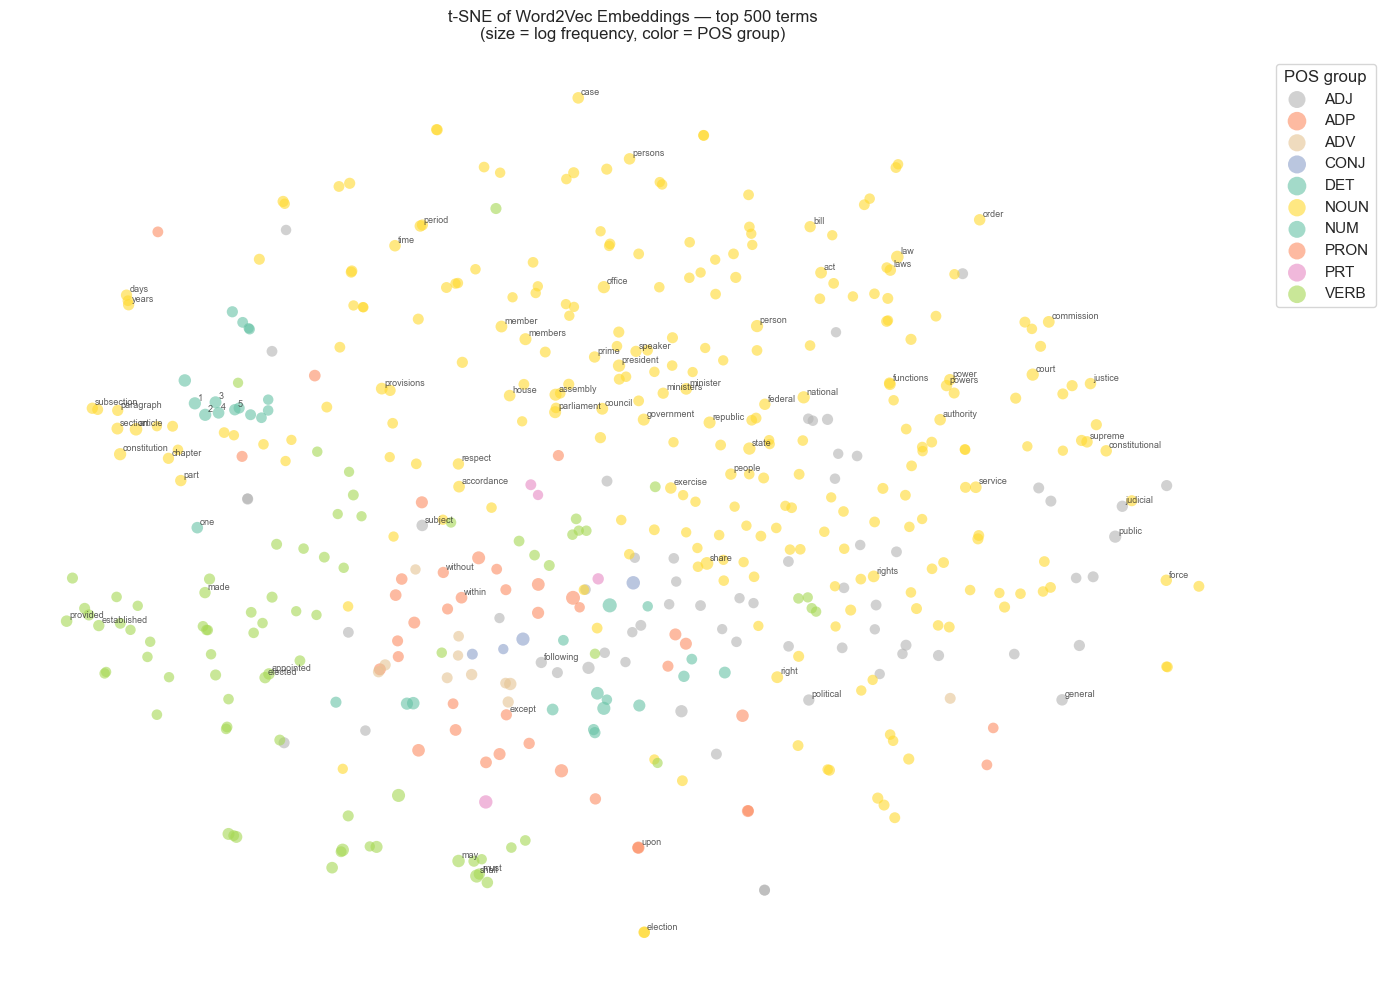

Plot saved.


In [13]:
pos_groups = TSNE_DF['max_pos_group'].dropna().unique()
palette    = dict(zip(pos_groups, sns.color_palette('Set2', len(pos_groups))))

fig, ax = plt.subplots(figsize=(14, 10))

for pos, grp in TSNE_DF.groupby('max_pos_group'):
    sizes = np.log1p(grp['n']) * 8
    ax.scatter(
        grp.x, grp.y,
        s          = sizes,
        color      = palette.get(pos, 'gray'),
        alpha      = 0.6,
        label      = pos,
        edgecolors = 'none'
    )

label_terms = (
    TSNE_DF[TSNE_DF['stop'] == 0]
    .nlargest(80, 'n')
    .index
)
for term in label_terms:
    row = TSNE_DF.loc[term]
    ax.annotate(
        term, xy=(row.x, row.y),
        fontsize=6.5, alpha=0.75,
        xytext=(2, 2), textcoords='offset points'
    )

ax.legend(title='POS group', bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=1.5)
ax.set_title(f't-SNE of Word2Vec Embeddings — top {N_PLOT} terms\n(size = log frequency, color = POS group)', pad=12)
ax.set_xticks([])
ax.set_yticks([])
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('figures/const_w2v_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### Cluster Description

*Fill in after running — look for a tight cluster that catches your eye and describe it:*

Example: *"A cluster in the lower-right quadrant groups terms like `parliament`, `senate`, `assembly`, `chamber`, and `legislature` — all nouns referring to legislative bodies. Their proximity suggests the model has learned that these terms appear in very similar syntactic contexts across constitutions, even when the specific institution names differ by country."*

## Save

In [14]:
TSNE_DF.to_csv(f'{output_dir}/const_TSNE.csv', index=True)
w2v_model.save(f'{output_dir}/const_w2v.model')
print('All outputs saved.')

All outputs saved.
